# United States — F-Score grid study: basket k = 25, random draws = 1000

One cell of the reviewer-suggested 3 x 3 x 2 grid (basket sizes 20/25/30 x
random-sample sizes 1,000/2,000/5,000 x two markets). Signals come from the
team-computed workbook (`data/processed/`, exact Piotroski conventions,
financial firms removed); prices from the cached Yahoo data. Formations are
July 1 using score year T-1 (one conservative timing rule for both markets);
the evaluation window ends 2025-12-31.

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW
and plain universe minimum-variance controls; denoised (not detoned) GMV;
primary measure fixed in advance = net-of-cost Sharpe (20 bp per side,
rf = 0); and the synergy test D = Sharpe(GMV) − Sharpe(EW) computed per
basket. All figures are saved at dpi = 300.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.team_scores import load_team_scores, sectors_from_scores
from fscore.grid import run_grid

MARKET, K, N_MC = "us", 25, 1000
YEARS = list(range(2021, 2026))
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)
TAG = "us_k25_mc1000"

scores = load_team_scores(MARKET, ROOT / "data")
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)
study = run_grid(MARKET, scores, prices, sectors, YEARS, k=K, n_mc=N_MC,
                 n_gmv=300, seed=42)
diag = study.diagnostics()
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,n_fscore_high,fscore_mean,fscore_basket_min,overlap_random_vs_fscore,overlap_expected
year,,,,,,,,,
2021,71,0,67,25,5,5.394,6.0,0.353,0.352
2022,72,0,68,25,17,6.611,7.0,0.347,0.347
2023,72,0,68,25,12,6.056,6.0,0.346,0.347
2024,75,0,71,25,15,6.067,7.0,0.335,0.333
2025,75,0,71,25,16,6.120,7.0,0.336,0.333


### 1. Summary (primary measure: net-of-cost Sharpe; rf = 0, costs 20 bp per side on one-way turnover)

In [2]:
summary = study.summary()
summary.round(3)

,cum_return,ann_return,ann_vol,sharpe,max_drawdown,net_ann_return,net_sharpe
fscore_EW,0.493,0.094,0.148,0.635,-0.276,0.091,0.617
fscore_GMV,0.512,0.097,0.129,0.752,-0.201,0.094,0.731
fscore_GMVsec,0.576,0.107,0.127,0.845,-0.215,0.104,0.824
fscore_high_EW,0.351,0.070,0.156,0.446,-0.233,0.067,0.429
value_EW,0.562,0.105,0.161,0.652,-0.238,0.102,0.636
universe_EW,0.536,0.101,0.145,0.696,-0.207,0.098,0.678
universe_GMV,0.331,0.066,0.126,0.525,-0.152,0.063,0.504


### 2. Yearly returns (July–June holding years; final year ends Dec 2025)

In [3]:
yearly = study.yearly_returns()
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV
date,,,,,,,
2021,6.1,8.3,6.7,11.4,7.0,7.5,6.7
2022,-16.7,-9.7,-9.5,-11.2,-9.8,-8.0,1.3
2023,15.5,4.8,6.8,11.1,24.3,16.7,-2.1
2024,24.3,28.6,32.1,16.8,15.8,16.4,9.4
2025,17.8,14.7,15.7,5.2,12.4,14.4,14.9


### 3. Placement vs the random distributions

In [4]:
rows = {}
for pool, label in [("mc_ew", "random (full universe)"),
                    ("mc_nonf_ew", "random (non-F-Score names)")]:
    frame = getattr(study, pool)
    if frame.shape[1]:
        for stat in ["sharpe", "ann_return"]:
            rows[(label, stat)] = study.placement("fscore_EW", pool, stat)
placement = pd.DataFrame(rows).T
placement.round(3)

percentile  p_value  n_draws  \
random (full universe)     sharpe           0.393    0.607   1000.0   
                           ann_return       0.373    0.627   1000.0   
random (non-F-Score names) sharpe           0.386    0.614   1000.0   
                           ann_return       0.336    0.664   1000.0   

                                       random_mean  random_std  fscore  
random (full universe)     sharpe            0.672       0.150   0.635  
                           ann_return        0.101       0.022   0.094  
random (non-F-Score names) sharpe            0.680       0.135   0.635  
                           ann_return        0.103       0.020   0.094

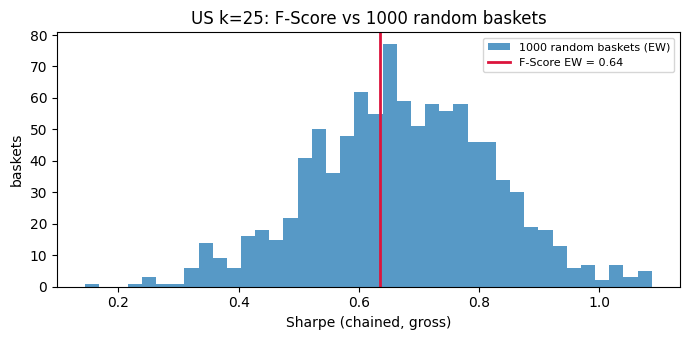

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sh = study.mc_metric(study.mc_ew, "sharpe")
ax.hist(sh, bins=40, alpha=0.75, label=f"{N_MC} random baskets (EW)")
fs = placement.loc[("random (full universe)", "sharpe"), "fscore"]
ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: F-Score vs {N_MC} random baskets")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_mc_hist.png", dpi=300)
plt.show()

### 4. Synergy test (reviewer priority 1): per-basket optimisation gain D = Sharpe(GMV) − Sharpe(EW)

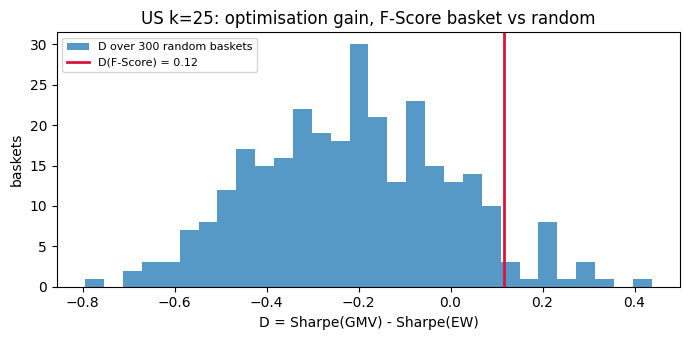

percentile         0.943
p_value            0.057
n_draws          300.000
random_mean       -0.212
random_std         0.214
D_fscore           0.116
D_random_mean     -0.212
D_random_std       0.214
n                300.000
dtype: float64

In [6]:
syn = study.synergy()
d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
          - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))], "sharpe")).dropna()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
ax.axvline(syn["D_fscore"], color="crimson", lw=2,
           label=f"D(F-Score) = {syn['D_fscore']:.2f}")
ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: optimisation gain, F-Score basket vs random")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_synergy_hist.png", dpi=300)
plt.show()
pd.Series(syn).round(3)

### 5. Track record and outputs

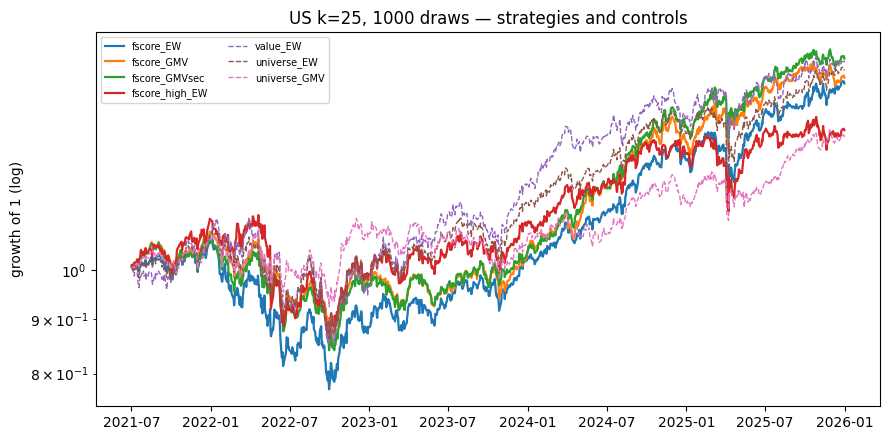

saved us_k25_mc1000


In [7]:
nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in nav.columns:
    ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
            ls="-" if c.startswith("fscore") else "--", label=c)
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
ax.set_title(f"{MARKET.upper()} k={K}, {N_MC} draws — strategies and controls")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_nav.png", dpi=300)
plt.show()

summary.to_csv(OUT / f"{TAG}_summary.csv")
placement.to_csv(OUT / f"{TAG}_placement.csv")
pd.Series(syn).to_frame("value").to_csv(OUT / f"{TAG}_synergy.csv")
yearly.to_csv(OUT / f"{TAG}_yearly_returns.csv")
diag.to_csv(OUT / f"{TAG}_diagnostics.csv")
print("saved", TAG)